# Axe 3 - Pourquoi subjectivement ?

---

Dans ce notebook, j'étudie les variables liées aux dimensions subjectives des employés (satisfaction, implication, équilibre de vie) afin d’identifier leurs relations potentielles avec l’attrition.

Ce notebook a pour objectif :

- d'explorer les variables de l'axe
- de les comparer à l'attrition
- d'analyser les interactions avec les autres axes 
- de visualiser et mettre en évidence les relations les plus structurantes



## 1. Préparation des données de l’axe

---

Dans cette section, les variables nécessaires à l'analyse de l'axe satisfaction et implication sont sélectionnées et préparées à partir du jeu de données nettoyé.
Les transformations réalisées sont spécifiques à cet axe.

### 1.1 Import des librairies et chargement des données


In [ ]:
# Import des librairies 

import pandas as pd
import pyarrow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display_html
from pathlib import Path

In [ ]:
# Définition des chemins

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

In [ ]:
# chargement du dataframe nettoyé
df_clean = pd.read_parquet(PROCESSED_DATA_DIR/"employees_clean.parquet")
df_clean.head(2)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7


### 1.2 Fonctions utilitaires


In [ ]:
# Préparation des variables
def prepare_satisfaction_variables(df):
    """
    Prépare et harmonise les variables de satisfaction, d'engagement
    et de performance (échelles ordinales).
    """
    satisfaction_label = {1: "Faible",
                          2: "Moyenne",
                          3: "Élevée",
                          4: "Très élevée"}

    cols_sat = ["EnvironmentSatisfaction",
                "JobSatisfaction",
                "RelationshipSatisfaction"]
    
    df[[c + "_label" for c in cols_sat]] = df[cols_sat].replace(satisfaction_label)

    df["WorkLifeBalance_label"] = df["WorkLifeBalance"].replace({
        1: "Insatisfaisant",
        2: "Satisfaisant",
        3: "Bon",
        4: "Excellent"})

    df["JobInvolvement_label"] = df["JobInvolvement"].replace({
        1: "Faible",
        2: "Modéré",
        3: "Élevé",
        4: "Très élevé"})

    df["PerformanceRating_label"] = df["PerformanceRating"].replace({
        1: "Faible",
        2: "Bonne",
        3: "Excellente",
        4: "Exceptionnelle" })

    return df

# Tableau de pourcentage variable univarié

def value_counts_percent(serie,round_n=3):

    """  Calcule la distribution (%) d'une variable catégorielle et retourne un DataFrame"""
    
    return (serie.value_counts(normalize=True).
            round(round_n).
            mul(100).
            reset_index(name="Pourcentage"))

# Tableau de pourcentage de variables bivariées
def groupby_percent(df,columns1,columns2,observed=True):
    """Calcule la distribution (%) de columns2 pour chaque modalité de columns1
    et retourne un DataFrame au format long. """
    return(df.groupby(columns1,observed=observed)[columns2].
           value_counts(normalize=True).
           round(2)
           *100).reset_index(name="Pourcentage")

# Tableau de moyenne de variables bivariées
def groupby_mean(df, columns1, columns2) :
    """Calcule la moyenne de distribution de columns2 pour chaque modalité de columns1
    et retourne un DataFrame """
    return(df.groupby(columns1, observed=True)[columns2].mean().round(2).reset_index(name="Moyenne"))

# Table pivot en pourcentage de variables bivariées
def pivot_percent(df,index,columns):
    """ Crée un tableau pivot (%) : lignes=index, colonnes=columns."""
    df = groupby_percent(df,index,columns)
    return(df.pivot(index=index, columns=columns,values="Pourcentage").fillna(0))


### 1.3 Construction et préparation des DataFrames satisfaction_implication et global


#### Colonnes incluses dans l'axe "Satisfaction et implication"

Cet axe regroupe les caractéristiques du ressenti et de l'investissement des employés dans la structure :

- Implication dans le travail  
- Satisfaction vis-à-vis de l’environnement de travail  
- Satisfaction au travail  
- Évaluation de la performance  
- Satisfaction des relations professionnelles  
- Équilibre vie professionnelle / vie personnelle  


In [ ]:
# colonnes condition de travail
cols_satisfaction_implication = ['JobInvolvement', 'EnvironmentSatisfaction','JobSatisfaction',
                                 "PerformanceRating",'RelationshipSatisfaction','WorkLifeBalance',"EmployeeNumber"]

# Création df_condition_Trav
df_satisfaction_implication = df_clean[cols_satisfaction_implication + ['Attrition']].copy()
df_satisfaction_implication.head(3)

,JobInvolvement,EnvironmentSatisfaction,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,WorkLifeBalance,EmployeeNumber,Attrition
0,3,2,4,3,1,1,1,Yes
1,2,3,2,4,4,3,2,No
2,2,4,3,3,2,3,4,Yes


#### Préparation des variables

Objectif : créer des variables explicites (labels) et harmoniser les échelles ordinales.

**Actions :**
- Harmoniser les échelles ordinales (1 → 4)
- Ordonner les catégories (si besoin)
- Transformer les variables binaires

**Renommage des codages et échelles des variables**

Toutes les variables de cet axe sont codées sur une échelle ordinale de 1 à 4.  
Une valeur plus élevée correspond systématiquement à une perception ou une évaluation plus positive, bien que les libellés diffèrent légèrement selon la variable.

**Variables de satisfaction (environnement, relations, travail)**

- **EnvironmentSatisfaction** : 1 Faible → 4 Très élevée  
- **JobSatisfaction** : 1 Faible → 4 Très élevée  
- **RelationshipSatisfaction** : 1 Faible → 4 Très élevée  
- **WorkLifeBalance** : 1 Insatisfaisant → 4 Excellent  

**Variables d'engagement et de performance**

- **JobInvolvement** : 1 Faible → 4 Très élevé  
- **PerformanceRating** : 1 Faible → 4 Exceptionnelle  

**Remarque :** *PerformanceRating* mesure un résultat observable (différent de la satisfaction).


In [ ]:
df_satisfaction_implication = prepare_satisfaction_variables(df_satisfaction_implication)

df_satisfaction_implication.head()


,JobInvolvement,EnvironmentSatisfaction,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,WorkLifeBalance,EmployeeNumber,Attrition,EnvironmentSatisfaction_label,JobSatisfaction_label,RelationshipSatisfaction_label,WorkLifeBalance_label,JobInvolvement_label,PerformanceRating_label
0,3,2,4,3,1,1,1,Yes,Moyenne,Très élevée,Faible,Insatisfaisant,Élevé,Excellente
1,2,3,2,4,4,3,2,No,Élevée,Moyenne,Très élevée,Bon,Modéré,Exceptionnelle
2,2,4,3,3,2,3,4,Yes,Très élevée,Élevée,Moyenne,Bon,Modéré,Excellente
3,3,4,3,3,3,3,5,No,Très élevée,Élevée,Élevée,Bon,Élevé,Excellente
4,3,1,2,3,4,3,7,No,Faible,Moyenne,Très élevée,Bon,Élevé,Excellente


**Transformation de l'attrition en variable numérique**

La variable *Attrition*, initialement codée sous forme catégorielle ("Yes"/"No"), a été transformée en variable numérique binaire (1/0) afin de faciliter les analyses quantitatives et le calcul de taux moyens.

In [ ]:

# Transformation de la variable Attrition
df_satisfaction_implication["Attrition_num"] = df_satisfaction_implication["Attrition"].map({"No": 0, "Yes": 1})
df_satisfaction_implication.head(2)

,JobInvolvement,EnvironmentSatisfaction,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,WorkLifeBalance,EmployeeNumber,Attrition,EnvironmentSatisfaction_label,JobSatisfaction_label,RelationshipSatisfaction_label,WorkLifeBalance_label,JobInvolvement_label,PerformanceRating_label,Attrition_num
0,3,2,4,3,1,1,1,Yes,Moyenne,Très élevée,Faible,Insatisfaisant,Élevé,Excellente,1
1,2,3,2,4,4,3,2,No,Élevée,Moyenne,Très élevée,Bon,Modéré,Exceptionnelle,0


**Ordonner les colonnes catégorielles** 

In [ ]:
# Nettoyer
df_satisfaction_implication["JobSatisfaction_label"] = (df_satisfaction_implication["JobSatisfaction_label"].astype(str).str.strip().replace({"Trés élevée": "Très élevée"}))
df_satisfaction_implication["WorkLifeBalance_label"] = (df_satisfaction_implication["WorkLifeBalance_label"].astype(str).str.strip())
df_satisfaction_implication["JobInvolvement_label"] = (df_satisfaction_implication["JobInvolvement_label"].astype(str).str.strip().replace({"Trés élevé": "Très élevé"}))

# ordre
ordre_satisfaction = ["Faible", "Moyenne", "Élevée", "Très élevée"]
ordre_equilibre = ["Insatisfaisant","Satisfaisant", "Bon", "Excellent"]
ordre_jobInvolvement = ["Faible", "Modéré", "Élevé", "Très élevé"]

# Convertir 
df_satisfaction_implication["JobSatisfaction_label"] = pd.Categorical(df_satisfaction_implication["JobSatisfaction_label"],
                                                                      categories=ordre_satisfaction,
                                                                      ordered=True)

df_satisfaction_implication["WorkLifeBalance_label"] = pd.Categorical(df_satisfaction_implication["WorkLifeBalance_label"],
                                                              categories=ordre_equilibre,
                                                              ordered=True)

df_satisfaction_implication["JobInvolvement_label"] = pd.Categorical(df_satisfaction_implication["JobInvolvement_label"],
                                                              categories=ordre_jobInvolvement,
                                                              ordered=True)


#### Fusion des DataFrames issus des axes précédents

**Chargement des jeux de données issus des axes précédents**


In [ ]:
df_conditions_travail = pd.read_parquet(PROCESSED_DATA_DIR/"df_conditions_travail.parquet")
df_conditions_personnelles = pd.read_parquet(PROCESSED_DATA_DIR/"df_conditions_personnelles.parquet")


**Fusion des jeux de données**

In [ ]:
cols_to_drop = ["Attrition"]

df_global = (df_satisfaction_implication
             .merge(df_conditions_travail.drop(columns=cols_to_drop, errors="ignore"),
                     on="EmployeeNumber", how="inner",validate="one_to_one")
             .merge(df_conditions_personnelles.drop(columns=cols_to_drop, errors="ignore"),
                     on="EmployeeNumber",how="inner", validate="one_to_one"))
df_global.head()

,JobInvolvement,EnvironmentSatisfaction,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,WorkLifeBalance,EmployeeNumber,Attrition,EnvironmentSatisfaction_label,JobSatisfaction_label,...,DistanceFromHome,Education,EducationField,Gender,MaritalStatus,NumCompaniesWorked,Tranche_Age,Tranche_Distance,Education_label,Tranche_EtsTravaille
0,3,2,4,3,1,1,1,Yes,Moyenne,Très élevée,...,1,2,Life Sciences,Femme,Single,8,36-45,1-5,College,+7
1,2,3,2,4,4,3,2,No,Élevée,Moyenne,...,8,1,Life Sciences,Homme,Married,1,46-55,6-10,Below College,0-1
2,2,4,3,3,2,3,4,Yes,Très élevée,Élevée,...,2,2,Other,Homme,Single,6,36-45,1-5,College,4-6
3,3,4,3,3,3,3,5,No,Très élevée,Élevée,...,3,4,Life Sciences,Femme,Married,1,26-35,1-5,Master,0-1
4,3,1,2,3,4,3,7,No,Faible,Moyenne,...,2,1,Medical,Homme,Married,9,26-35,1-5,Below College,+7


**Vérification de l'intégrité des données**

Contrôle des identifiants (*EmployeeNumber*) : valeurs manquantes, doublons et dimensions des jeux de données.


In [ ]:
for name, d in [("personnelles", df_conditions_personnelles),
                ("travail", df_conditions_travail),
                ("satisfaction", df_satisfaction_implication)]:
    print(name, d["EmployeeNumber"].isna().sum(), d["EmployeeNumber"].duplicated().sum(), d.shape)

print("global", df_global.shape)


personnelles 0 0 (1470, 13)
travail 0 0 (1470, 26)
satisfaction 0 0 (1470, 15)
global (1470, 50)


### 1.4 Sauvegarde des DataFrame


In [ ]:
df_satisfaction_implication.to_parquet(PROCESSED_DATA_DIR/"df_satisfaction_implication.parquet",index=False)

df_global.to_parquet(PROCESSED_DATA_DIR/"df_global.parquet",index=False)


## 2. Analyse individuelle des variables : Dimensions subjectives

---

Dans cette section, l'analyse porte sur plusieurs caractéristiques de la satisfaction et de l'implication des employés, afin de mieux comprendre le ressenti de la population étudiée.

Les variables sont analysées selon deux sous-thèmes :

- **la satisfaction** : perception et ressenti (environnement, relations, équilibre)
- **l'implication** : comportement et investissement (évalué par l'entreprise)

Certaines variables seront analysées de manière plus approfondie que d'autres.
Cette analyse repose sur une approche **descriptive**, basée sur l'étude des **distributions**, à l'aide de **tableaux de proportions** et de **visualisations graphiques**.

Pour compléter l'analyse catégorielle, une moyenne des scores de satisfaction et d'implication est calculée comme indicateur synthétique.

### 2.1 La satisfaction

Dans cette section, **la satisfaction** est analysée à travers plusieurs dimensions complémentaires : l'environnement de travail, vis-à-vis de son travail, les relations professionnelles et l'équilibre entre vie professionnelle et vie personnelle.

Les variables étudiées sont les suivantes :

- **EnvironmentSatisfaction** : Niveau de satisfaction vis-à-vis de l'environnement et des conditions de travail  
- **JobSatisfaction** : Niveau de satisfaction de l’employé vis-à-vis de son travail.  
- **RelationshipSatisfaction** : Niveau de satisfaction vis-à-vis des relations professionnelles (collègues, manager)  
- **WorkLifeBalance** : Niveau de satisfaction par rapport à l'équilibre entre vie professionnelle et vie personnelle


Dans le cadre de cette analyse :
- **EnvironmentSatisfaction** et **RelationshipSatisfaction** feront l'objet d'une analyse descriptive légère.
-  **JobSatisfaction** et **WorkLifeBalance** seront analysées de manière plus détaillée.


Les variables de ce sous-thème sont décrites à travers leurs répartitions afin de mieux comprendre la structure des postes au sein de l'entreprise.

**Le niveau de satisfaction vis-à-vis de l'environnement et des conditions de travail**

**Tableau des proportions**

In [ ]:
environmentSatisfaction_count = value_counts_percent(df_satisfaction_implication["EnvironmentSatisfaction_label"])
environmentSatisfaction_count

,EnvironmentSatisfaction_label,Pourcentage
0,Élevée,30.8
1,Très élevée,30.3
2,Moyenne,19.5
3,Faible,19.3


On observe qu'une majorité des employés **(environ 61 %)** déclarent un niveau de satisfaction vis-à-vis de l'environnement et des conditions de travail **élevé** (≈ 31 %) ou **très élevé** (≈ 30 %).

À l'inverse, les niveaux les moins représentés sont les niveaux de satisfaction **faible** (≈ 20 %) et **moyenne** (≈ 19 %).

Cette exploration met en évidence les grandes lignes d'un élément contextuel de la satisfaction au travail.

**Le niveau de satisfaction vis-à-vis de son travail**

**Tableau des proportions**

In [ ]:

jobSatisfaction_count = value_counts_percent(df_satisfaction_implication["JobSatisfaction_label"])
display(jobSatisfaction_count)


display(f'La moyenne du niveau de satisfaction lié au travail exercé des employés est de {df_satisfaction_implication["JobSatisfaction"].mean().round(2)} soit une satisfaction qui tend vers élevé')
display(f'La médiane du niveau de satisfaction lié au travail exercé des employés est de {df_satisfaction_implication["JobSatisfaction"].median().round(2)} soit une satisfaction élevé')

,JobSatisfaction_label,Pourcentage
0,Très élevée,31.2
1,Élevée,30.1
2,Faible,19.7
3,Moyenne,19.0


'La moyenne du niveau de satisfaction lié au travail exercé des employés est de 2.73 soit une satisfaction qui tend vers élevé'

'La médiane du niveau de satisfaction lié au travail exercé des employés est de 3.0 soit une satisfaction élevé'

**Distribution des employés selon leur niveau de satisfaction vis-à-vis de leur travail**

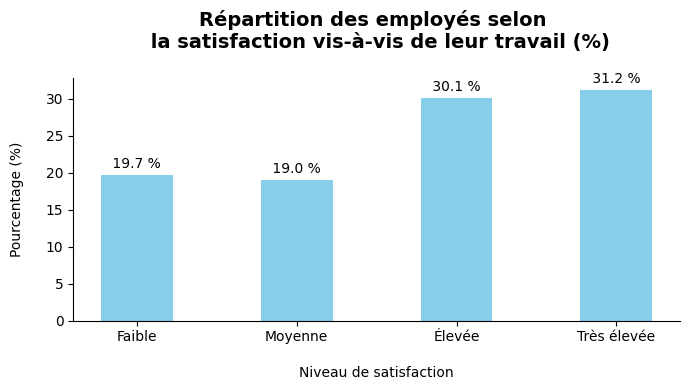

In [ ]:
# Trier
jobSatisfaction_count = jobSatisfaction_count.sort_values("JobSatisfaction_label", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x = np.arange(len(jobSatisfaction_count.index))
y = jobSatisfaction_count["Pourcentage"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f'{v : .1F} % ' for v in y], padding=3)

# Axes et labels

ax.set_xticks(x)
ax.set_xticklabels(jobSatisfaction_count["JobSatisfaction_label"])

ax.set_xlabel("\nNiveau de satisfaction")
ax.set_ylabel("Pourcentage (%)\n")
ax.set_title("Répartition des employés selon \n la satisfaction vis-à-vis de leur travail (%)\n ", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show()


Ce graphique met en évidence deux niveaux de satisfaction liés au travail exercé particulièrement représentés :
- **très élevée** (≈ 31 %)
- **élevée** (≈ 30 % )

À l'inverse, les niveaux de satisfaction **faible** et **moyen** sont moins représentés, chacun concernant environ 19 à 20 % des employés.

**Le taux moyen de satisfaction** est de **2,73**, indiquant un niveau global tendant vers une satisfaction élevée.

Cette exploration fournit une première vision du niveau de satisfaction professionnelle lié au poste occupé au sein de l'entreprise.
La majorité des salariés déclarent ainsi un niveau de satisfaction **élevé ou très élevé**, suggérant un vécu professionnel globalement favorable.

**Le niveau de satisfaction vis-à-vis de leurs relations professionnelles (collègues, manager)**

**Tableau des proportions**

In [ ]:
relationshipSatisfaction_count = value_counts_percent(df_satisfaction_implication["RelationshipSatisfaction_label"])
relationshipSatisfaction_count

,RelationshipSatisfaction_label,Pourcentage
0,Élevée,31.2
1,Très élevée,29.4
2,Moyenne,20.6
3,Faible,18.8


On observe qu'une large majorité des employés déclarent un niveau de satisfaction **élevé ou très élevé** concernant leurs relations professionnelles, soit environ **62 %** de l'effectif.

À l'inverse, les niveaux de satisfaction **moyen et faible** sont moins représentés, chacun représentant approximativement **19 à 20 %** des employés.

**Niveau de satisfaction concernant l'équilibre entre vie professionnelle et vie personnelle**

**Tableau des proportions**

In [ ]:
workLifeBalance_count = value_counts_percent(df_satisfaction_implication["WorkLifeBalance_label"])
display(workLifeBalance_count)


display(f"La moyenne du niveau de satisfaction entre l'équilibre vie pro/perso est de {df_satisfaction_implication["WorkLifeBalance"].mean().round(2)} soit un équilibre qui tend vers un bon équilibre")
display(f"La médiane du niveau de satisfaction entre l'équilibre vie pro/perso est de {df_satisfaction_implication["WorkLifeBalance"].median().round(2)} soit un bon équilibre")

,WorkLifeBalance_label,Pourcentage
0,Bon,60.7
1,Satisfaisant,23.4
2,Excellent,10.4
3,Insatisfaisant,5.4


"La moyenne du niveau de satisfaction entre l'équilibre vie pro/perso est de 2.76 soit un équilibre qui tend vers un bon équilibre"

"La médiane du niveau de satisfaction entre l'équilibre vie pro/perso est de 3.0 soit un bon équilibre"

**Distribution des employés en fonction de leur niveau d'équilibre entre vie professionnelle et vie personnelle**

Ce graphique met en évidence qu'un niveau d'équilibre entre vie professionnelle et vie personnelle est particulièrement représenté : le niveau **bon équilibre**, déclaré par environ **61 %** des employés.

À l'inverse, le niveau d'équilibre **insatisfaisant** apparaît comme le plus minoritaire, avec approximativement **5 %** des déclarations.

Cette exploration fournit une première échelle de lecture du ressenti des salariés concernant l'équilibre vie professionnelle / vie personnelle.
La majorité des salariés déclarent ainsi un équilibre satisfaisant, suggérant une perception globalement positive de cette dimension.

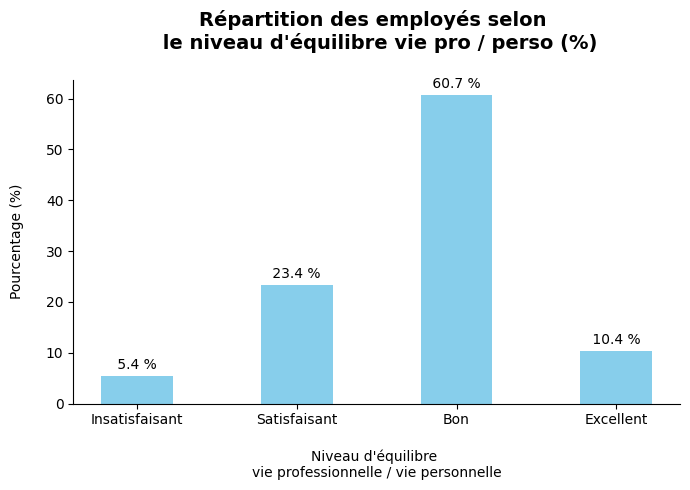

In [ ]:
# Trier
workLifeBalance_count = workLifeBalance_count.sort_values("WorkLifeBalance_label", ascending=True)

# Graphique

fig , ax = plt.subplots(figsize=(7,5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x = np.arange(len(workLifeBalance_count.index))
y = workLifeBalance_count["Pourcentage"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f'{v : .1F} % ' for v in y], padding=3)

# Axes et labels

ax.set_xticks(x)
ax.set_xticklabels(workLifeBalance_count["WorkLifeBalance_label"])

ax.set_xlabel("\nNiveau d'équilibre \nvie professionnelle / vie personnelle")
ax.set_ylabel("Pourcentage (%)\n")
ax.set_title("Répartition des employés selon \n le niveau d'équilibre vie pro / perso (%)\n ", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show()


**Mini-synthèse - Satisfaction**

L'analyse de la satisfaction montre qu'une large majorité des employés déclarent un niveau de satisfaction **élevé à très élevé**, aussi bien concernant leur poste, leur environnement de travail que leurs relations professionnelles.

Cette tendance se retrouve également dans l'équilibre vie professionnelle / vie personnelle, avec une majorité de salariés déclarant disposer d'un **bon équilibre**.

### 2.2 Implication

Cette section s'intéresse aux variables liées à **l'implication et l'investissement** des employés.

Les variables analysées sont :

- **JobInvolvement** : niveau d'engagement professionnel de l'employé dans son travail  
- **PerformanceRating** : évaluation du niveau de performance observée  
  *(proxy indirect de l'engagement, à interpréter avec prudence)* 

L'analyse conjointe de JobInvolvement et PerformanceRating permet de distinguer l'engagement perçu par le salarié de la performance évaluée par l'entreprise.

Dans le cadre de cette analyse :

- **JobInvolvement** fera l'objet d'une analyse descriptive légère.
- **PerformanceRating** sera analysé de manière plus détaillée.

 
Ces variables sont analysées de manière descriptive afin de caractériser la distribution des niveaux d'engagement au sein de l'entreprise.


**Le niveau d'engagement professionnel des employés**

**Tableau des proportions**

In [ ]:
jobInvolvement_count = value_counts_percent(df_satisfaction_implication["JobInvolvement_label"])
display(jobInvolvement_count)

display(f"La moyenne du niveau d'engagement des employés est de {df_satisfaction_implication["JobInvolvement"].mean().round(2)} soit une implication qui tend vers un niveau élevé")
display(f"La médiane du niveau d'engagement des employés est de {df_satisfaction_implication["JobInvolvement"].median().round(2)} soit une implication d'un niveau élevé")

,JobInvolvement_label,Pourcentage
0,Élevé,59.0
1,Modéré,25.5
2,Très élevé,9.8
3,Faible,5.6


"La moyenne du niveau d'engagement des employés est de 2.73 soit une implication qui tend vers un niveau élevé"

"La médiane du niveau d'engagement des employés est de 3.0 soit une implication d'un niveau élevé"

**Distribution des employés en fonction de leur niveau d'engagement professionnel.**

Ce graphique met en évidence qu'un niveau d'engagement professionnel est particulièrement représenté : **environ 59 %** des employés déclarent un niveau d'engagement **élevé**.

À l'inverse, les niveaux d'engagement **faible** (≈ 6 %) et **très élevé**(≈ 10 %) sont plus minoritaires.

Le taux moyen d'engagement tend vers un niveau **élevé**, indiquant une implication professionnelle globalement importante au sein de la population étudiée.

Cette exploration fournit une première lecture de la perception qu'ont les salariés de leur propre niveau d'implication.


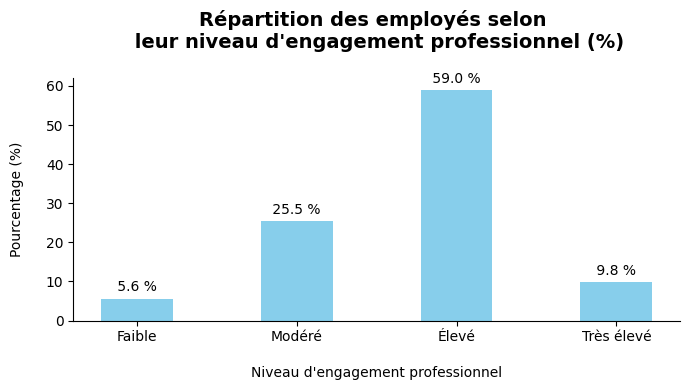

In [ ]:
# Trier
jobInvolvement_count = jobInvolvement_count.sort_values("JobInvolvement_label", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x = np.arange(len(jobInvolvement_count.index))
y = jobInvolvement_count["Pourcentage"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f'{v : .1F} % ' for v in y], padding=3)

# Axes et labels

ax.set_xticks(x)
ax.set_xticklabels(jobInvolvement_count["JobInvolvement_label"])

ax.set_xlabel("\nNiveau d'engagement professionnel")
ax.set_ylabel("Pourcentage (%)\n")
ax.set_title("Répartition des employés selon \n leur niveau d'engagement professionnel (%)\n ", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show()


**L'évaluation du niveau de performance observée**

**Tableau des proportions**

In [ ]:
performanceRating_count = value_counts_percent(df_satisfaction_implication["PerformanceRating_label"])
performanceRating_count

,PerformanceRating_label,Pourcentage
0,Excellente,84.6
1,Exceptionnelle,15.4


On observe que seuls deux niveaux d'évaluation de la performance sont représentés : **Excellente** et **Exceptionnelle**.

Le niveau **Excellente** est largement majoritaire, concernant environ **85 %** de la population.

**Mini-synthèse - implication**

L'analyse de l'implication met en évidence qu'une large majorité des employés déclarent un niveau d'engagement professionnel **élevé**.

Cette tendance est également observée dans l'évaluation de la performance, la majorité des salariés étant classée à un niveau de performance **élevé**.


Après avoir décrit les principales caractéristiques de la satisfaction et implication des employés, cette section s'intéresse désormais à leur relation avec l'attrition.

L'objectif est d'observer si certaines dimensions subjectives telles que la satisfaction et l'implication présentent des différences de taux d'attrition selon les groupes étudiés.

## 3. Attrition - Satisfaction/Implication

---

### 3.1 Introduction

Dans cette section, j'analyse la relation entre l'attrition et le niveau de satisfaction et d'implication au travail.

Les résultats doivent être interprétés comme des indicateurs de sur- ou sous-exposition, et non comme des relations causales.

##### Tableau de proportions Attrition Yes / No


In [ ]:
attrition_count = value_counts_percent(df_satisfaction_implication['Attrition'])

attrition_count

,Attrition,Pourcentage
0,No,83.9
1,Yes,16.1


D'après ce tableau, le taux d'attrition global observé dans le jeu de données est d'environ **16 %**, ce qui constitue le niveau de référence pour les analyses suivantes.

Dans les analyses suivantes, l'accent est mis sur le taux d'attrition (Attrition = Yes), les non-départs représentant le complément à 100 %.

### 3.2 Analyse de l'attrition selon les variables de la satisfaction et de l'implication


Dans cette partie, les sous-thèmes précédents sont réutilisés pour analyser la relation entre les variables de satisfaction et d'implication et l'attrition.

Certaines variables de cet axe ont été explorées individuellement, mais n'ont pas été retenues dans l'analyse de l'attrition, en raison de distributions peu contrastées ou d'un intérêt analytique limité observé lors de l'exploration initiale.

L'analyse combine :

- Des distributions en pourcentage, permettant d'observer les taux d'attrition selon les niveaux de satisfaction et d'implication,
- et le calcul de moyennes de l'attrition (variable binaire), utilisées comme indicateurs synthétiques afin de comparer les groupes selon leur statut de départ.

Les variables sélectionnées sont comparées à partir de tableaux de proportions et de visualisations graphiques.
Cette approche permet d'identifier des différences de taux d'attrition entre les groupes, avant toute analyse approfondie ou modélisation.


#### 3.2.1 Attrition et satisfaction

Dans cette partie, les variables analysées avec l'attrition sont

1. Le niveau de satisfaction vis-à-vis de l'environnement et des conditions de travail
2. le niveau de satisfaction selon leur travail
3. Le niveau de satisfaction vis-à-vis de leurs relations professionnelles (collègues, manager)
4. le niveau de satisfaction concernant l'équilibre entre vie professionnelle et vie personnelle


**Attrition et Le niveau de satisfaction vis-à-vis de l'environnement et des conditions de travail**

**Tableaux descriptifs (Proportion ­­(%) et Moyenne)**

In [ ]:

# Tableau de proportion
environmentSatisfaction_attrition = df_satisfaction_implication[["EnvironmentSatisfaction_label", "Attrition"]]

## pivot : ligne = niveau de satisfaction, colonne= attrition, valeur =pourcentage
pivot_environmentSatisfaction_attrition = pivot_percent(environmentSatisfaction_attrition, "EnvironmentSatisfaction_label","Attrition")


# Tableau de Moyenne
environmentSatisfaction_attrition_mean = groupby_mean(df_satisfaction_implication, "EnvironmentSatisfaction","Attrition_num")

# Tableau côte à côte

display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
        t1=pivot_environmentSatisfaction_attrition.sort_values("Yes", ascending=False).to_html(),
        t2=environmentSatisfaction_attrition_mean.to_html()
    ),
    raw=True
)

Attrition,No,Yes
EnvironmentSatisfaction_label,,
Faible,75.0,25.0
Moyenne,85.0,15.0
Élevée,86.0,14.0
Très élevée,87.0,13.0
,EnvironmentSatisfaction,Moyenne
0,1,0.25
1,2,0.15
2,3,0.14
3,4,0.13


On observe que les employés déclarant un niveau **faible** de satisfaction vis-à-vis de l'environnement et des conditions de travail présentent le taux d'attrition le plus élevé (**≈ 25 %**).

À l'inverse, le taux d'attrition est le plus faible pour les employés déclarant un niveau de satisfaction **très élevé** (≈ **13** %).

Cette tendance est confirmée par l'analyse des taux moyens d'attrition, qui diminuent progressivement lorsque le niveau de satisfaction augmente.

**Attrition et le niveau de satisfaction vis-à-vis de leur travail**

**Tableaux descriptifs (Proportion ­­(%) et Moyenne)**

In [ ]:
# Tableau de proportion
jobSatisfaction_attrition = df_satisfaction_implication[["JobSatisfaction_label", "Attrition"]]

## pivot : ligne = niveau de satisfaction, colonne= attrition, valeur =pourcentage
pivot_jobSatisfaction_attrition = pivot_percent(jobSatisfaction_attrition,"JobSatisfaction_label", "Attrition")


# Tableau de Moyenne
jobSatisfaction_attrition_mean = groupby_mean(df_satisfaction_implication,"JobSatisfaction", "Attrition_num")


# Tableau côte à côte

display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
        t1=pivot_jobSatisfaction_attrition.sort_values("Yes", ascending=False).to_html(),
        t2=jobSatisfaction_attrition_mean.sort_values("Moyenne", ascending=False).to_html()
    ),
    raw=True
)

Attrition,No,Yes
JobSatisfaction_label,,
Faible,77.0,23.0
Élevée,83.0,17.0
Moyenne,84.0,16.0
Très élevée,89.0,11.0
,JobSatisfaction,Moyenne
0,1,0.23
2,3,0.17
1,2,0.16
3,4,0.11


**Analyse de la relation entre le niveau de satisfaction vis-à-vis de leur travail et l'attrition**

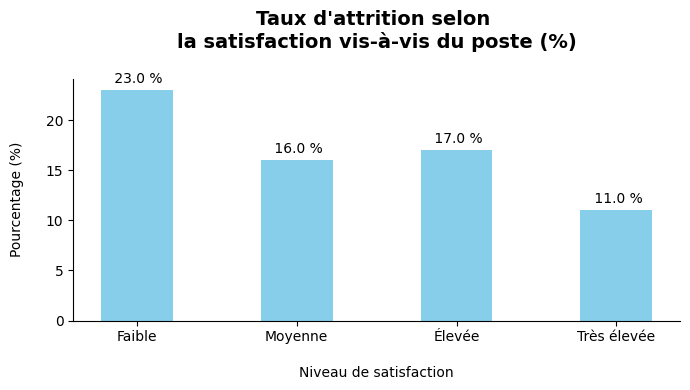

(None,)

In [ ]:
pivot_jobSatisfaction_attrition = pivot_jobSatisfaction_attrition.sort_values("JobSatisfaction_label", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_jobSatisfaction_attrition.index))
y = pivot_jobSatisfaction_attrition["Yes"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_jobSatisfaction_attrition.index)

ax.set_xlabel("\nNiveau de satisfaction")
ax.set_ylabel("Pourcentage (%)\n")
ax.set_title("Taux d'attrition selon \nla satisfaction vis-à-vis du poste (%)\n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

Ce graphique met en évidence que les employés déclarant un niveau **faible** de satisfaction vis-à-vis de leur poste présentent le taux d'attrition le plus élevé (**≈ 25 %**).

Le taux d'attrition diminue ensuite pour les niveaux de satisfaction **moyens et élevé,** avec des valeurs comprises entre **16 % et 17 %**, et atteint son niveau le plus faible chez les salariés déclarant une satisfaction **très élevée** (**≈ 11 %**).

Cette tendance est cohérente avec les taux moyens d'attrition observés et met en évidence une relation décroissante entre la satisfaction vis-à-vis du poste et l'attrition.

**Attrition et Le niveau de satisfaction des relations professionnelles (collègues, manager)**

**Tableaux descriptifs (Proportion ­­(%) et Moyenne)**

In [ ]:
# Tableau de proportion
relationshipSatisfaction_attrition = df_satisfaction_implication[["RelationshipSatisfaction_label", "Attrition"]]

pivot_relationshipSatisfaction_attrition = pivot_percent(relationshipSatisfaction_attrition, "RelationshipSatisfaction_label", "Attrition")

# Tableau de moyenne
relationshipSatisfaction_attrition_mean = groupby_mean(df_satisfaction_implication,"RelationshipSatisfaction", "Attrition_num")

# Tableau côte à côte

display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
        t1=pivot_relationshipSatisfaction_attrition.sort_values("Yes", ascending=False).to_html(),
        t2=relationshipSatisfaction_attrition_mean.to_html()
    ),
    raw=True)

Attrition,No,Yes
RelationshipSatisfaction_label,,
Faible,79.0,21.0
Moyenne,85.0,15.0
Très élevée,85.0,15.0
Élevée,85.0,15.0
,RelationshipSatisfaction,Moyenne
0,1,0.21
1,2,0.15
2,3,0.15
3,4,0.15


On observe que le taux d'attrition est plus élevé chez les employés déclarant un niveau de satisfaction **faible** dans leurs relations professionnelles (≈ **21 %**).

À l'inverse, les salariés déclarant un niveau de satisfaction **moyen, élevé ou très élevé** présentent un taux d'attrition identique, fixé à **15 %**.

Le taux moyen d'attrition observé confirme cette tendance.

**Attrition et le niveau de satisfaction concernant l'équilibre entre vie professionnelle et vie personnelle**

**Tableaux descriptifs (Proportion ­­(%) et Moyenne)**

In [ ]:
# Tableau de proportion
workLifeBalance_attrition = df_satisfaction_implication[["WorkLifeBalance_label", "Attrition"]]

pivot_workLifeBalance_attrition = pivot_percent(workLifeBalance_attrition,"WorkLifeBalance_label", "Attrition")

# Tableau de moyenne
workLifeBalance_attrition_mean = groupby_mean(df_satisfaction_implication,"WorkLifeBalance", "Attrition_num")

# Tableau côte à côte

display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
        t1=pivot_workLifeBalance_attrition.sort_values("Yes", ascending=False).to_html(),
        t2=workLifeBalance_attrition_mean.sort_values("Moyenne", ascending=False).to_html()
    ),
    raw=True)

Attrition,No,Yes
WorkLifeBalance_label,,
Insatisfaisant,69.0,31.0
Excellent,82.0,18.0
Satisfaisant,83.0,17.0
Bon,86.0,14.0
,WorkLifeBalance,Moyenne
0,1,0.31
3,4,0.18
1,2,0.17
2,3,0.14


**Analyse de la relation entre Le niveau de satisfaction concernant l'équilibre entre vie professionnelle et vie personnelle et l'attrition**

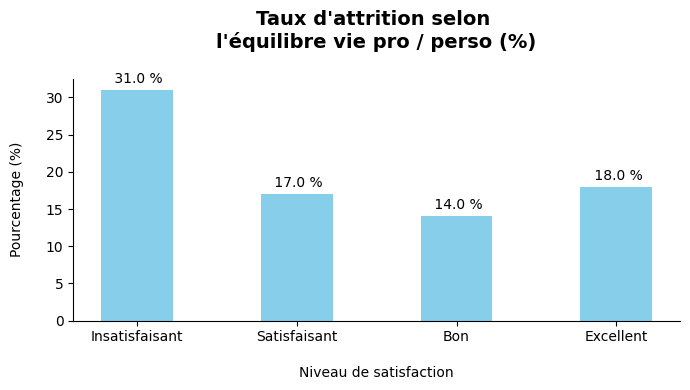

In [ ]:
pivot_workLifeBalance_attrition= pivot_workLifeBalance_attrition.sort_values("WorkLifeBalance_label", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_workLifeBalance_attrition.index))
y = pivot_workLifeBalance_attrition["Yes"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_workLifeBalance_attrition.index)

ax.set_xlabel("\nNiveau de satisfaction")
ax.set_ylabel("Pourcentage (%)\n")
ax.set_title("Taux d'attrition selon \nl'équilibre vie pro / perso (%)\n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show()

On observe que le taux d'attrition est plus élevé chez les employés déclarant un niveau **insatisfaisant** d'équilibre entre vie professionnelle et vie personnelle (≈ **31 %**).

Le taux d'attrition diminue pour les niveaux d'équilibre jugés **satisfaisant** (≈ 17 %) et **bon** (≈ 14 %).

En revanche, une légère remontée du taux d'attrition est observée pour les employés déclarant un niveau d'équilibre **excellent** (≈ **18 %)**.

Cette configuration est également retrouvée lorsque l'on observe les taux moyens d'attrition par niveau d'équilibre.

#### 3.2.2 Attrition et l'implication


Dans cette partie, les variables analysées avec l'attrition sont

1. L'engagement 
2. et la performance observée.


**Attrition et le niveau d'engagement professionnel des employés**

**Tableaux descriptifs (Proportion ­­(%) et Moyenne)**

In [ ]:
# Tableau de proportion
jobInvolvement_attrition = df_satisfaction_implication[["JobInvolvement_label", "Attrition"]]

pivot_jobInvolvement_attrition = pivot_percent(jobInvolvement_attrition,"JobInvolvement_label","Attrition")

# Tableau de moyenne
jobInvolvement_attrition_mean = groupby_mean(df_satisfaction_implication,"JobInvolvement","Attrition_num")

# Tableau côte à côte

display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
            t1=pivot_jobInvolvement_attrition.sort_values("Yes", ascending=False).to_html(),
            t2=jobInvolvement_attrition_mean.sort_values("Moyenne",ascending=False).to_html()),
            raw=True)

Attrition,No,Yes
JobInvolvement_label,,
Faible,66.0,34.0
Modéré,81.0,19.0
Élevé,86.0,14.0
Très élevé,91.0,9.0
,JobInvolvement,Moyenne
0,1,0.34
1,2,0.19
2,3,0.14
3,4,0.09


**Analyse de la relation entre le niveau d'engagement professionnel et l'attrition**

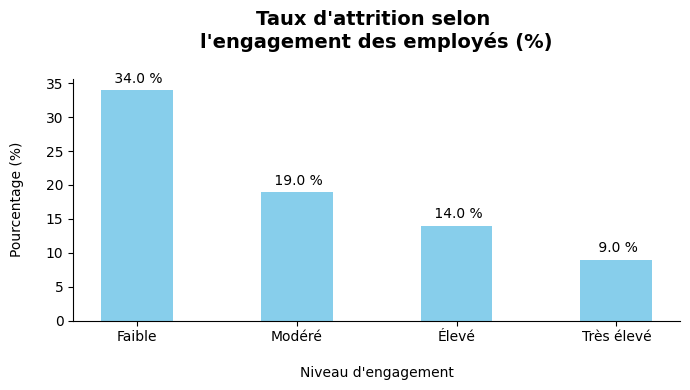

In [ ]:
pivot_jobInvolvement_attrition = pivot_jobInvolvement_attrition.sort_values("JobInvolvement_label", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_jobInvolvement_attrition.index))
y = pivot_jobInvolvement_attrition["Yes"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_jobInvolvement_attrition.index)

ax.set_xlabel("\nNiveau d'engagement")
ax.set_ylabel("Pourcentage (%)\n")
ax.set_title("Taux d'attrition selon \nl'engagement des employés (%)\n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show()

Ce graphique met en évidence que les salariés déclarant un niveau d'engagement **faible** présentent le taux d'attrition le plus élevé (≈ **34 %**).

À l'inverse, le taux d'attrition est le plus faible chez les salariés déclarant un niveau d'engagement **très élevé** (≈ 9 %).

Le taux moyen d'attrition diminue progressivement à mesure que le niveau d'engagement déclaré augmente.

**Attrition et l'évaluation du niveau de performance observée**

**Tableaux descriptifs (Proportion ­­(%) et Moyenne)**

In [ ]:
# Tableau de proportion
performanceRating_attrition = df_satisfaction_implication[["PerformanceRating_label", "Attrition"]]

pivot_performanceRating_attrition = pivot_percent(performanceRating_attrition,"PerformanceRating_label","Attrition")

# Tableau de moyenne
performanceRating_attrition_mean = groupby_mean(df_satisfaction_implication,"PerformanceRating","Attrition_num")

# Tableau côte à côte

display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
            t1=pivot_performanceRating_attrition.sort_values("Yes", ascending=False).to_html(),
            t2=performanceRating_attrition_mean.to_html()),
            raw=True)

Attrition,No,Yes
PerformanceRating_label,,
Excellente,84.0,16.0
Exceptionnelle,84.0,16.0
,PerformanceRating,Moyenne
0,3,0.16
1,4,0.16


On observe que le taux d'attrition est identique, autour de **16 %**, pour les deux niveaux de performance observés : **excellente** et **exceptionnelle**.

#### 3.3 Résultats clés - Satisfaction / Implication et attrition

---

Les analyses mettent en évidence plusieurs résultats marquants concernant la relation entre les niveaux d'engagement, de satisfaction et l'attrition.

- **Les taux d'attrition les plus élevés sont observés chez les salariés présentant le niveau d'engagement les plus faibles.**  
  À l'inverse, le taux d'attrition diminue nettement à mesure que le niveau d'engagement augmente, traduisant une relation inverse claire entre ces deux variables.

- **Un schéma comparable est observé pour les différentes dimensions de la satisfaction au travail** (satisfaction vis-à-vis de leur travail, de l'environnement et des conditions de travail, ainsi que des relations professionnelles).  
  Les niveaux faibles de satisfaction sont associés à des taux d'attrition plus élevés, tandis que les niveaux de satisfaction plus élevés présentent des taux de départ plus faibles.  
  Cette décroissance, bien que non strictement linéaire, demeure nettement observable.

- Par ailleurs, **les salariés déclarant un équilibre vie professionnelle / vie personnelle insatisfaisant présentent les taux d'attrition les plus élevés.**  
  Le taux d'attrition diminue pour des niveaux d'équilibre jugés satisfaisants ou bons, avant de remonter légèrement pour le niveau d'équilibre déclaré excellent.

- **Enfin, le niveau de performance observé par l'entreprise présente des variations de taux d'attrition limitées**, sans différenciation nette entre les groupes analysés.



Une fois les comparaisons simples réalisées, j'explore les facteurs explicatifs de l'axe afin d'identifier d'éventuels patterns ou corrélations.

## 4. Facteurs associés à la satisfaction et à l'implication

---

### 4.1 Introduction


Cette section ne vise pas à expliquer directement l'attrition, mais à identifier des facteurs associés aux niveaux de satisfaction et d'implication au travail, susceptibles de jouer un rôle intermédiaire dans les mécanismes de départ observés précédemment.

Elle analyse les relations entre certaines variables organisationnelles et personnelles, et les niveaux de satisfaction et d'implication, afin d'évaluer dans quelle mesure ces dimensions peuvent constituer des facteurs corrélés intermédiaires dans la relation à l'attrition.

Les analyses reposent sur des tableaux croisés (%) et des visualisations graphiques descriptives, réalisés par type de facteur (organisationnel ou personnel), à partir des variables de satisfaction et d'implication identifiées comme structurantes dans les axes précédents.

**Variables analysées :**

- **Satisfaction au travail**
  - Satisfaction vis-à-vis de leur travail et heures supplémentaires  
  - Satisfaction vis-à-vis de leur travail et ancienneté avec le manager  
  - Équilibre vie professionnelle / vie personnelle et distance domicile-travail  

- **Implication au travail**
  - Implication et ancienneté dans le poste  
  - Implication et heures supplémentaires



### 4.2 Analyse des variables organisationnelles et expérience collaborateur


Les variables sont analysées à partir de tableaux croisés (%) et de visualisations graphiques descriptives.


#### 4.2.1 Satisfaction dans leur travail et variables organisationnelles

Cette sous-section analyse les relations entre certaines caractéristiques organisationnelles et les niveaux de satisfaction vis-à-vis de leur travail, identifiés comme susceptibles de contribuer aux mécanismes d'attrition observés précédemment.

**Relation entre la satisfaction vis-à-vis de leur travail et les heures supplémentaires**

**Tableaux descriptifs (proportions (%) et moyennes)**


In [ ]:
# Tableau de proportion
jobSatisfaction_Overtime = df_global[["OverTime","JobSatisfaction_label"]]

pivot_jobSatisfaction_Overtime = pivot_percent(jobSatisfaction_Overtime,"OverTime","JobSatisfaction_label")


# Tableau de moyenne

jobSatisfaction_Overtime_mean = groupby_mean(df_global,"OverTime", "JobSatisfaction")

# Tableau côte à côte
display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
            t1=pivot_jobSatisfaction_Overtime.to_html(),
            t2=jobSatisfaction_Overtime_mean.to_html()),
            raw=True)

Tableau de proportions (%) 
 
 
 
 JobSatisfaction_label 
 Faible 
 Moyenne 
 Élevée 
 Très élevée 
 
 
 OverTime 
 
 
 
 
 
 
 
 
 No 
 19.0 
 20.0 
 30.0 
 30.0 
 
 
 Yes 
 20.0 
 17.0 
 29.0 
 34.0 
 
 
 
 
 
 Tableau de moyenne 
 
 
 
 
 OverTime 
 Moyenne 
 
 
 
 
 0 
 No 
 2.71 
 
 
 1 
 Yes 
 2.77

**Visualisation**

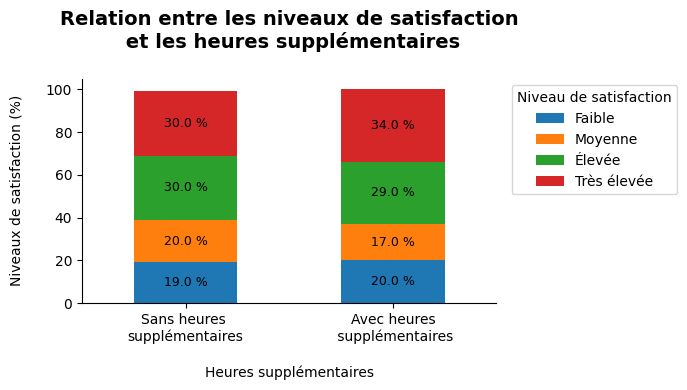

In [ ]:
fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Bar stacked
pivot_jobSatisfaction_Overtime.plot(kind="bar",stacked=True, ax=ax)


# Pourcentage affiché
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:.1f} %" for v in container.datavalues],
        label_type="center",
        fontsize=9)

# Axes et labels
ax.set_xlabel("\nHeures supplémentaires")
ax.set_ylabel("Niveaux de satisfaction (%)\n")
ax.set_title("Relation entre les niveaux de satisfaction\n et les heures supplémentaires\n",
             fontsize=14, fontweight="bold")

ax.legend(title="Niveau de satisfaction", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xticklabels(["Sans heures \nsupplémentaires", "Avec heures\n supplémentaires"], rotation=0)


fig.tight_layout()
plt.show()


Les distributions des niveaux de satisfaction vis-à-vis du poste apparaissent globalement similaires selon la présence d'heures supplémentaires.

La structure des profils de satisfaction est comparable entre les deux groupes, avec une prédominance des niveaux **élevé et très élevé**, représentant environ **60 %** des salariés dans les deux cas.

Les variations observées concernent principalement les niveaux intermédiaires, sans modification marquée de la structure globale.

Le score moyen de satisfaction est identique pour les salariés avec ou sans heures supplémentaires (**2,71**), confirmant l'absence de différence notable entre les groupes.

**Relation entre satisfaction vis-à-vis du poste et la durée de collaboration avec le manager**

**Tableaux descriptifs (Proportion ­­(%) et Moyenne)**

In [ ]:
# Tableau de proportion
jobSatisfaction_YearsWithCurrManager = df_global[["Tranche_CurManager","JobSatisfaction_label"]]

pivot_jobSatisfaction_YearsWithCurrManager = pivot_percent(df_global, "Tranche_CurManager", "JobSatisfaction_label")

# Tableau de moyenne
jobSatisfaction_YearsWithCurrManage_mean = groupby_mean(df_global, "Tranche_CurManager", "JobSatisfaction")

# Tableau côte à côte
display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
            t1=pivot_jobSatisfaction_YearsWithCurrManager.to_html(),
            t2=jobSatisfaction_YearsWithCurrManage_mean.sort_values("Moyenne", ascending=False).to_html()),
            raw=True)

Tableau de proportions (%) 
 
 
 
 JobSatisfaction_label 
 Faible 
 Moyenne 
 Élevée 
 Très élevée 
 
 
 Tranche_CurManager 
 
 
 
 
 
 
 
 
 < 1 an 
 18.0 
 19.0 
 31.0 
 32.0 
 
 
 1-2 ans 
 18.0 
 19.0 
 33.0 
 30.0 
 
 
 3-5 ans 
 22.0 
 20.0 
 26.0 
 33.0 
 
 
 6-10 ans 
 19.0 
 19.0 
 30.0 
 31.0 
 
 
 > 10 ans 
 27.0 
 16.0 
 29.0 
 27.0 
 
 
 
 
 
 Tableau de moyenne 
 
 
 
 
 Tranche_CurManager 
 Moyenne 
 
 
 
 
 0 
 < 1 an 
 2.77 
 
 
 1 
 1-2 ans 
 2.74 
 
 
 3 
 6-10 ans 
 2.74 
 
 
 2 
 3-5 ans 
 2.70 
 
 
 4 
 > 10 ans 
 2.56

**Visualisation**

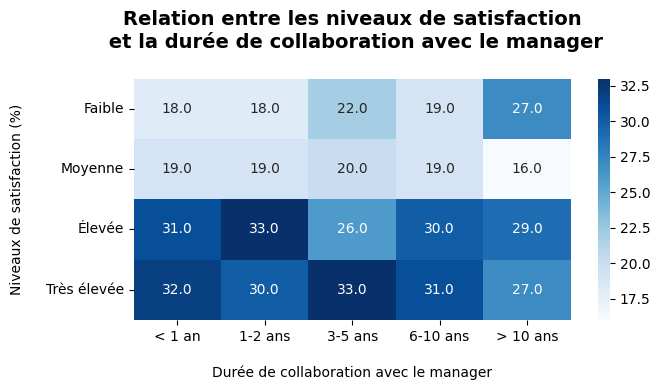

In [ ]:
plt.figure(figsize=(7,4))

sns.heatmap(pivot_jobSatisfaction_YearsWithCurrManager.T, cmap="Blues", fmt=".1F", annot=True, cbar=True)
plt.gca().yaxis_inverted()

plt.xlabel("\nDurée de collaboration avec le manager")
plt.ylabel("Niveaux de satisfaction (%)\n")
plt.title("Relation entre les niveaux de satisfaction\n et la durée de collaboration avec le manager\n",
             fontsize=14, fontweight="bold")

plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

La visualisation montre que, quelle que soit la durée de collaboration avec le manager, les niveaux de satisfaction **élevés et très élevés** demeurent majoritaires.

La structure des profils de satisfaction apparaît globalement stable entre les différentes tranches de durée de collaboration, sans relation linéaire clairement identifiable.

Une inflexion est toutefois observée pour la tranche de collaboration supérieure à 10 ans, marquée par une augmentation relative de la satisfaction faible et par un score moyen de satisfaction plus bas (2,56 contre environ 2,70-2,74 pour les autres tranches).

Cette évolution suggère une hétérogénéité des perceptions de satisfaction pour les relations managériales de très longue durée, sans remettre en cause la prédominance globale des niveaux élevés de satisfaction.


#### 4.2.2 Implication au travail et variables organisationnelles

Cette sous-section explore la relation entre certaines variables organisationnelles et le niveau d'implication au travail, dans une logique comparable à celle appliquée à la satisfaction.

**Relation entre l'engagement et l'ancienneté dans le poste**

**Tableaux descriptifs (Proportion ­­(%) et Moyenne)**

In [ ]:
# Tableau de proportion
jobInvolvement_Tranche_PosteAnciennete = df_global[["Tranche_PosteAnciennete", "JobInvolvement_label"]]

pivot_jobInvolvement_Tranche_PosteAnciennete = pivot_percent(jobInvolvement_Tranche_PosteAnciennete,"Tranche_PosteAnciennete", "JobInvolvement_label")

# Tableau de moyenne
jobInvolvement_Tranche_PosteAnciennete_mean = groupby_mean(df_global, "Tranche_PosteAnciennete", "JobInvolvement")

# Tableau côte à côte
display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
            t1=pivot_jobInvolvement_Tranche_PosteAnciennete.to_html(),
            t2=jobInvolvement_Tranche_PosteAnciennete_mean.sort_values("Moyenne",ascending=False).to_html()),
            raw=True)


Tableau de proportions (%) 
 
 
 
 JobInvolvement_label 
 Faible 
 Modéré 
 Élevé 
 Très élevé 
 
 
 Tranche_PosteAnciennete 
 
 
 
 
 
 
 
 
 ≤ 2 ans 
 5.0 
 26.0 
 59.0 
 9.0 
 
 
 3-5 ans 
 6.0 
 24.0 
 60.0 
 10.0 
 
 
 6-10 ans 
 5.0 
 25.0 
 59.0 
 11.0 
 
 
 > 10 ans 
 8.0 
 26.0 
 56.0 
 10.0 
 
 
 
 
 
 Tableau de moyenne 
 
 
 
 
 Tranche_PosteAnciennete 
 Moyenne 
 
 
 
 
 2 
 6-10 ans 
 2.75 
 
 
 1 
 3-5 ans 
 2.74 
 
 
 0 
 ≤ 2 ans 
 2.72 
 
 
 3 
 > 10 ans 
 2.69

**Visualisation**

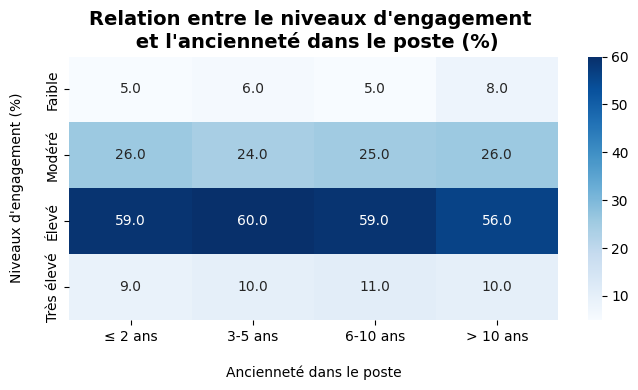

In [ ]:
plt.figure(figsize=(7,4))

sns.heatmap(pivot_jobInvolvement_Tranche_PosteAnciennete.T, cmap="Blues", fmt=".1F", cbar=True, annot=True)

plt.xlabel("\nAncienneté dans le poste")
plt.ylabel("Niveaux d'engagement (%)\n")
plt.title("Relation entre le niveaux d'engagement \n et l'ancienneté dans le poste (%)",
          fontweight="bold", fontsize=14)


plt.tight_layout()
plt.show()

Cette visualisation montre que le niveau d'engagement **élevé** est largement dominant, quelle que soit l'ancienneté dans le poste.

La structure globale des niveaux d'engagement apparaît stable entre les différentes tranches d'ancienneté, avec une faible représentation des niveaux d'engagement faibles.

Des variations limitées sont observées dans la répartition des niveaux d'engagement très élevés, sans qu'une relation linéaire ou progressive claire ne se dégage.

Les scores moyens d'engagement se situent entre 2,72 et 2,75, avec une légère diminution pour la tranche d'ancienneté supérieure à 10 ans (2,69), suggérant une hétérogénéité modérée des niveaux d'engagement pour les durées de poste les plus longues.

**Relation entre l'engagement et les heures supplémentaires**


**Tableaux descriptifs (Proportion ­­(%) et Moyenne)**

In [ ]:
# Tableau de proportion
jobInvolvement_OverTime = df_global[["OverTime", "JobInvolvement_label"]]

pivot_jobInvolvement_OverTime = pivot_percent(jobInvolvement_OverTime, "OverTime", "JobInvolvement_label")

# Tableau de moyenne
jobInvolvement_OverTime_mean = groupby_mean(df_global, "OverTime_num", "JobInvolvement")

# Tableau côte à côte
display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
            t1=pivot_jobInvolvement_OverTime.to_html(),
            t2=jobInvolvement_OverTime_mean.to_html()),
            raw=True)



Tableau de proportions (%) 
 
 
 
 JobInvolvement_label 
 Faible 
 Modéré 
 Élevé 
 Très élevé 
 
 
 OverTime 
 
 
 
 
 
 
 
 
 No 
 6.0 
 26.0 
 59.0 
 10.0 
 
 
 Yes 
 6.0 
 25.0 
 59.0 
 10.0 
 
 
 
 
 
 Tableau de moyenne 
 
 
 
 
 OverTime_num 
 Moyenne 
 
 
 
 
 0 
 0 
 2.73 
 
 
 1 
 1 
 2.73

**Visualisation**

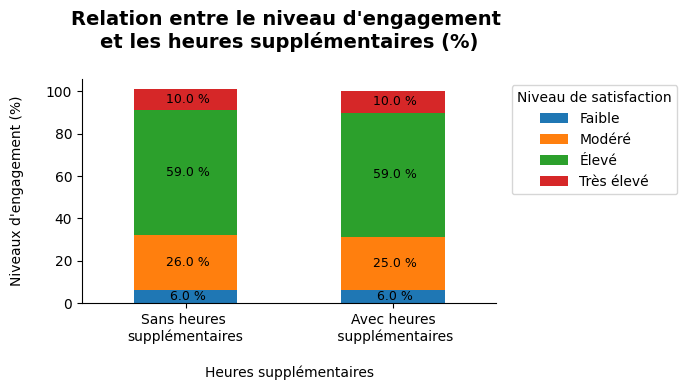

In [ ]:
fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Barplot
pivot_jobInvolvement_OverTime.plot(kind="bar", stacked=True, ax=ax)

# Affichage du pourcentage

for container in ax.containers:
    ax.bar_label(container,
                 labels=[f"{v : .1f} %" for v in container.datavalues],
                 label_type="center",
                 fontsize=9)

ax.set_xlabel("\nHeures supplémentaires")
ax.set_ylabel("Niveaux d'engagement (%)\n")
ax.set_title("Relation entre le niveau d'engagement \net les heures supplémentaires (%)\n",
             fontsize=14, fontweight="bold")

ax.legend(title="Niveau de satisfaction", bbox_to_anchor=(1.02, 1), loc="upper left",)
ax.set_xticklabels(["Sans heures \nsupplémentaires", "Avec heures\n supplémentaires"], rotation=0)

fig.tight_layout()
plt.show()

Le graphique met en évidence des profils d'engagement très similaires selon la présence d'heures supplémentaires.

Le niveau d'engagement **élevé** est largement majoritaire dans les deux groupes.

Le score moyen d'engagement est identique pour les salariés avec ou sans heures supplémentaires (2,73), indiquant **l'absence de différenciation notable** entre les groupes.

### 4.3 Variables personnelles et expérience collaborateur

---

Les analyses précédentes ont mis en évidence des patterns structurants liés aux trajectoires de vie. Cette sous-section vise à explorer dans quelle mesure certaines caractéristiques individuelles peuvent être associées aux niveaux de satisfaction et d'implication.

Les variables sont analysées à partir de tableaux croisés (%) et de visualisations graphiques descriptives.

#### 4.3.1 Satisfaction / Implication et variables personnelles

**Relation entre l'équilibre vie professionnelle et personnelle et la distance domicile-travail**

**Tableaux descriptifs (Proportion ­­(%) et Moyenne)**

In [ ]:
# Tableau de proportion
worklife_DistanceFromHome = df_global[["Tranche_Distance","WorkLifeBalance_label"]]

pivot_workLifeBalance_DistanceFromHome = pivot_percent(worklife_DistanceFromHome, "Tranche_Distance", "WorkLifeBalance_label")

# Tableau de moyenne
worklife_DistanceFromHome_mean = groupby_mean(df_global, "Tranche_Distance", "WorkLifeBalance")

# Tableau côte à côte
display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
            t1=pivot_workLifeBalance_DistanceFromHome.to_html(),
            t2=worklife_DistanceFromHome_mean.sort_values('Moyenne',ascending=False).to_html()),
            raw=True)



Tableau de proportions (%) 
 
 
 
 WorkLifeBalance_label 
 Insatisfaisant 
 Satisfaisant 
 Bon 
 Excellent 
 
 
 Tranche_Distance 
 
 
 
 
 
 
 
 
 1-5 
 5.0 
 24.0 
 59.0 
 12.0 
 
 
 6-10 
 6.0 
 22.0 
 63.0 
 9.0 
 
 
 11-20 
 5.0 
 26.0 
 60.0 
 9.0 
 
 
 >20 
 6.0 
 23.0 
 62.0 
 9.0 
 
 
 
 
 
 Tableau de moyenne 
 
 
 
 
 Tranche_Distance 
 Moyenne 
 
 
 
 
 0 
 1-5 
 2.79 
 
 
 1 
 6-10 
 2.75 
 
 
 3 
 >20 
 2.74 
 
 
 2 
 11-20 
 2.73

**Visualisation**

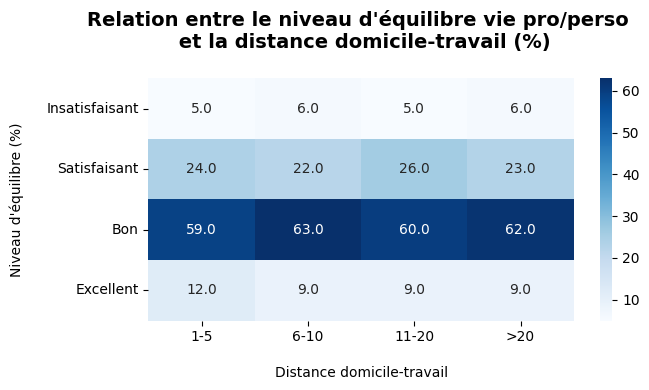

In [ ]:
plt.figure(figsize=(7,4))

sns.heatmap(pivot_workLifeBalance_DistanceFromHome.T, cmap='Blues', cbar=True, annot=True, fmt=".1f")

plt.xlabel("\nDistance domicile-travail")
plt.ylabel("Niveau d'équilibre (%)\n")
plt.title("Relation entre le niveau d'équilibre vie pro/perso \n et la distance domicile-travail (%)\n",
          fontsize=14, fontweight="bold")

plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Cette visualisation met en évidence **une stabilité globale** des niveaux d'équilibre entre vie professionnelle et vie personnelle selon la distance domicile-travail.

Le niveau de « **bon équilibre** » est largement majoritaire, quelle que soit la tranche de distance considérée, tandis que les niveaux jugés insatisfaisants restent très faiblement représentés.

Les variations observées entre les différentes tranches de distance demeurent limitées et ne modifient pas la structure générale des profils d'équilibre.

Les scores moyens d'équilibre se situent entre **2,73 et 2,79**, avec un niveau légèrement plus élevé pour la tranche de distance 1-5, sans toutefois traduire une différenciation marquée entre les groupes.



Après avoir analysé ces relations, cette section synthétise les principaux patterns observés.

### 4.4 Synthèse des Patterns transversaux

---

Les analyses des facteurs organisationnels et individuels associés à la satisfaction et à l'engagement mettent en évidence plusieurs patterns, à la fois structurants et faiblement structurants.

- **Pattern 1 - Faible structuration de la satisfaction et de l'engagement par les heures supplémentaires**  

La comparaison des profils de satisfaction et d'engagement selon le recours aux heures supplémentaires met en évidence des distributions très proches entre les groupes.

Quel que soit le statut vis-à-vis des heures supplémentaires, les salariés se positionnent majoritairement sur des niveaux de satisfaction élevés à très élevés. Les écarts observés restent limités et ne traduisent pas de différenciation marquée des profils.

Un constat similaire est observé pour l'engagement : le niveau d'engagement élevé est largement dominant, indépendamment de la réalisation d'heures supplémentaires.

Dans l'ensemble, ces résultats suggèrent que le recours aux heures supplémentaires constitue un facteur faiblement structurant de la satisfaction et de l'engagement, lesquels semblent davantage dépendre de dimensions organisationnelles ou individuelles plus larges.

- **Pattern 2 - Stabilité globale de la satisfaction et de l'engagement, avec des fragilités ponctuelles sur les trajectoires longues**

Les niveaux de satisfaction au poste et d'engagement apparaissent globalement stables selon l'ancienneté dans le poste et la durée de collaboration avec le manager.

Dans l'ensemble, les salariés se positionnent majoritairement sur des niveaux élevés à très élevés de satisfaction, quel que soit le temps passé dans le poste ou auprès du même manager. Une structuration comparable est observée pour l'engagement, marqué par une prédominance du niveau élevé sur l'ensemble des tranches d'ancienneté.

Toutefois, certaines trajectoires longues, notamment chez les salariés collaborant depuis plus de dix ans avec le même manager, présentent une légère augmentation des niveaux de satisfaction plus faibles ainsi qu'une baisse relative de l'engagement moyen.

Ces éléments suggèrent que si l'ancienneté et la stabilité managériale ne structurent pas fortement la satisfaction et l'engagement, elles peuvent s'accompagner de fragilités ponctuelles sur le long terme.


- **Pattern 3 - Indépendance marquée de l'équilibre vie professionnelle / vie personnelle vis-à-vis de la distance domicile-travail**

L'analyse de la relation entre l'équilibre vie professionnelle / vie personnelle et la distance domicile-travail met en évidence une forte stabilité des perceptions, quel que soit l'éloignement géographique.

La majorité des salariés se positionne sur un niveau d'équilibre jugé « bon », indépendamment de la distance parcourue. Les variations observées entre les catégories de distance restent limitées et ne traduisent pas de structuration nette des niveaux d'équilibre.

Ces résultats indiquent que la distance domicile-travail constitue un facteur faiblement discriminant de la perception de l'équilibre vie professionnelle / vie personnelle, laquelle semble davantage dépendre d'autres modalités organisationnelles.



# 5. Résultats clés 

---

- La satisfaction et l'implication apparaissent comme des dimensions centrales associées à l'attrition.
    Les taux d'attrition les plus élevés concernent principalement les salariés présentant de faibles niveaux de satisfaction, d'engagement ou un équilibre vie professionnelle / vie personnelle jugé insatisfaisant.

- Les facteurs organisationnels explorés (heures supplémentaires, ancienneté, durée de collaboration avec le manager, distance domicile-travail) structurent peu directement les niveaux de satisfaction et d'engagement.
    Les analyses montrent des profils globalement stables selon ces variables, sans différenciation marquée.

- Toutefois, certaines fragilités apparaissent sur les trajectoires longues, notamment en termes de satisfaction et d'engagement, suggérant que ces dimensions peuvent évoluer dans le temps sans être directement liées à une variable organisationnelle unique.

- Ces résultats indiquent que la satisfaction et l'engagement constituent des mécanismes intermédiaires majeurs dans la compréhension de l'attrition, dépendant de facteurs organisationnels et individuels plus larges et moins directement observables.




# 6. Conclusion de l'axe "Satisfaction / Implication"

---

Cet axe s'est concentré sur l'analyse des dimensions subjectives du vécu des employés, à travers la satisfaction au travail et le niveau d'implication.

Le croisement de ces variables avec l'attrition met en évidence que les niveaux de satisfaction, d'engagement et d'équilibre vie professionnelle / vie personnelle jouent un rôle important dans les départs. Les salariés déclarant des niveaux faibles sur ces dimensions présentent des taux d'attrition plus élevés, confirmant le caractère central du ressenti dans la décision de quitter l'entreprise.

En revanche, l'analyse des relations entre ces dimensions subjectives et les variables organisationnelles ou personnelles montre des profils globalement stables. Les perceptions de satisfaction et d'engagement varient peu selon les conditions observées, et les différences mises en évidence restent limitées ou ponctuelles.

Ces résultats suggèrent que, si la satisfaction et l'implication sont fortement associées à l'attrition, elles ne sont pas entièrement expliquées par les facteurs organisationnels et individuels étudiés dans cet axe. D'autres éléments, plus larges ou moins directement observables, semblent intervenir dans la construction du ressenti des salariés.

Ainsi, l'étude de la satisfaction et de l'implication apporte une compréhension du **ressenti subjectif des employés** et permet de répondre partiellement à la question : *« pourquoi certains salariés restent ou partent »*.  
Elle souligne toutefois la nécessité de compléter cette approche par une réflexion plus globale, notamment à travers la synthèse des axes et les recommandations proposées.

---